# NumPyro implementation of the 2 moons distribution

In [ ]:
!pip install numpyro
!pip install diffrax

In [1]:
%pylab inline
import jax
import jax.numpy as np
import numpyro.distributions as dist

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


/usr/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
@jax.jit
def make_two_mooons(sigma):
  """
  Function that gives you the log probability of the two moons distribution.
  """
  resolution = 1024
  outer_circ_x = np.cos(np.linspace(0, np.pi, resolution))
  outer_circ_y = np.sin(np.linspace(0, np.pi, resolution))
  inner_circ_x = 1 - np.cos(np.linspace(0, np.pi, resolution))
  inner_circ_y = 1 - np.sin(np.linspace(0, np.pi, resolution)) - .5

  X = np.append(outer_circ_x, inner_circ_x)
  Y = np.append(outer_circ_y, inner_circ_y)
  coords = np.vstack([X,Y])

  base_sigma=0.05
  s = np.sqrt(sigma**2 + base_sigma**2)
  # We approximate the 2 moons with a large mixture
  distribution = dist.MixtureSameFamily(
      dist.Categorical(probs=np.ones(2*resolution)/resolution/2),
      dist.MultivariateNormal(loc=coords.T, scale_tril=s*np.eye(2)[None].repeat(2*resolution, axis=0))
  )
  return distribution

(-1.0, 2.0)

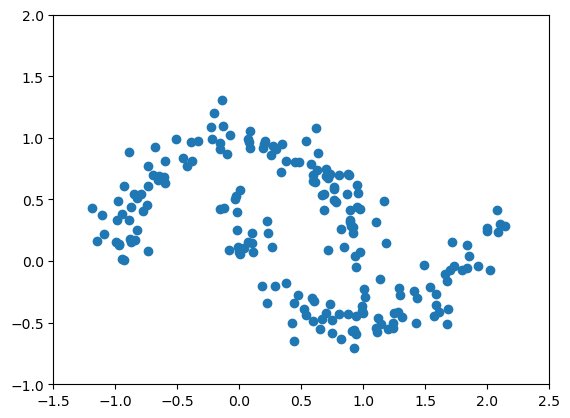

In [3]:
# Sample from the distribution and plot it
rng_key = jax.random.PRNGKey(seed=0)
distribution = make_two_mooons(0.1)
samps = distribution.sample(rng_key, sample_shape=(200,))

scatter(samps[:,0], samps[:,1])
xlim(-1.5,-1.5+4)
ylim(-1.,-1.+3)

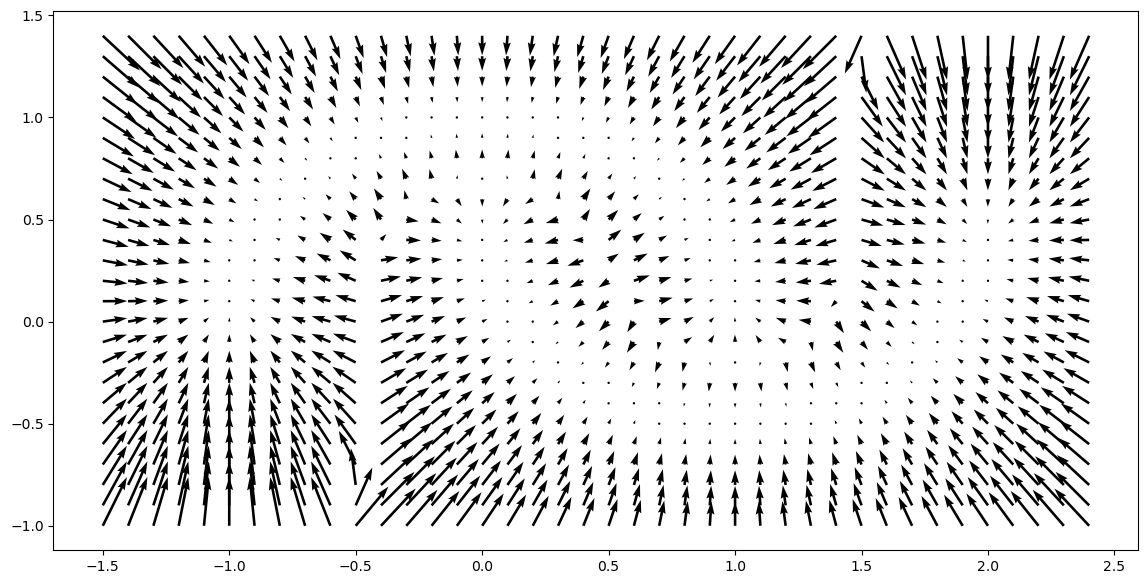

In [4]:
# But now we can also compute the gradients of log p :-)
grads = jax.vmap(jax.grad(distribution.log_prob))

X = np.arange(-1.5, 2.5, 0.1)
Y = np.arange(-1, 1.5, 0.1)
points = stack(meshgrid(X, Y), axis=-1).reshape((-1, 2))
g = grads(points).reshape([len(Y), len(X),2])

figure(figsize=(14,7))
quiver(X, Y, g[:,:,0], g[:,:,1]);

## Implementation of a diffusion model

In [5]:
import jax
import jax.numpy as jnp
import diffrax
import lineax as lx

def log_p(x, sigma=0.):
  return make_two_mooons(sigma).log_prob(x).squeeze()

score_fn = jax.vmap(jax.grad(log_p), in_axes=(0,None))

def ve_sde_sample(score_fn, x_init, key, sigma_min=0.01, sigma_max=10.0, N=128):
    """Sample from a VE-SDE diffusion model via reverse-time SDE.

    Forward VE-SDE:  dx = sqrt(d[sigma^2(t)]/dt) dw
    Reverse VE-SDE:  dx = -sigma(t)^2 * score(x, t) dt + sigma(t) dw_bar

    with sigma(t) = sigma_min * (sigma_max/sigma_min)^t
    """

    def sigma(t):
        return sigma_min * (sigma_max / sigma_min) ** t

    def drift(t, y, args):
        s = sigma(t)
        # d[sigma^2]/dt = sigma^2 * 2*log(sigma_max/sigma_min)
        score = score_fn(y, s)
        return -s**2 * 2 * jnp.log(sigma_max / sigma_min) * score

    def diffusion(t, y, args):
        s = sigma(t)
        diffusion_coeff_scalar = s * jnp.sqrt(2 * jnp.log(sigma_max / sigma_min))
        # Return a Lineax DiagonalLinearOperator as recommended by Diffrax 0.7.0+
        diagonal = jnp.full(y.shape[-1], diffusion_coeff_scalar) # Create a diagonal vector of size num_dims
        return lx.DiagonalLinearOperator(diagonal)

    # Reverse time: integrate from t=1 to t=0
    brownian_motion = diffrax.VirtualBrownianTree(
        t0=0.0, t1=1.0, tol=1e-3, shape=x_init.shape, key=key
    )

    terms = diffrax.MultiTerm(
        diffrax.ODETerm(drift),
        diffrax.ControlTerm(diffusion, brownian_motion),
    )

    solver = diffrax.Euler()
    sol = diffrax.diffeqsolve(
        terms,
        solver,
        t0=1.0,
        t1=0.0,
        dt0=-1.0 / N,
        y0=x_init,
        args=None,
        saveat=diffrax.SaveAt(ts=jnp.linspace(1.0, 0.0, N))
    )

    return sol.ys


key = jax.random.PRNGKey(0)
k1, k2 = jax.random.split(key)
x_init = jax.random.normal(k1, (128,2))  # start from noise

sample_score_fn = jax.vmap(jax.grad(log_p), in_axes=(0,None))

samples = ve_sde_sample(sample_score_fn, x_init, k2)

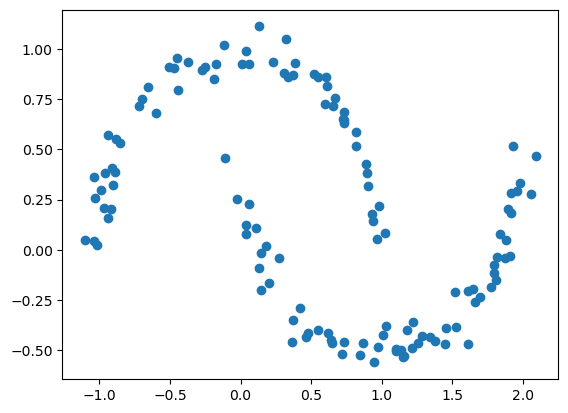

In [6]:
scatter(samples[-1,:,0], samples[-1,:,1])

## LATINO: Denoising Inverse Problem on Two Moons

Simplified version of the LATINO algorithm (Spagnoletti et al., 2025) for a 2D denoising problem.

**Setup:** Given noisy observations $y = x + n$ where $x \sim p_{\text{two moons}}$ and $n \sim \mathcal{N}(0, \sigma_n^2 I)$, recover $x$.

**Simplified LATINO** (no autoencoder, PF-ODE instead of consistency model):

For $k = 1, \ldots, N$:
1. **Noise:** $x_{\text{noisy}} = x^{(k-1)} + \sigma_k \varepsilon$, &ensp; $\varepsilon \sim \mathcal{N}(0,I)$
2. **Denoise via PF-ODE:** $u^{(k)} = \text{ODE}(x_{\text{noisy}}, \sigma_k \to 0)$ &ensp; using score $\nabla_x \log p_{\sigma}(x)$
3. **Proximal step:** $x^{(k)} = \frac{\delta_k \, y + \sigma_n^2 \, u^{(k)}}{\delta_k + \sigma_n^2}$

where $\sigma_k$ decreases (annealing) and $\delta_k = \sigma_k^2$.

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


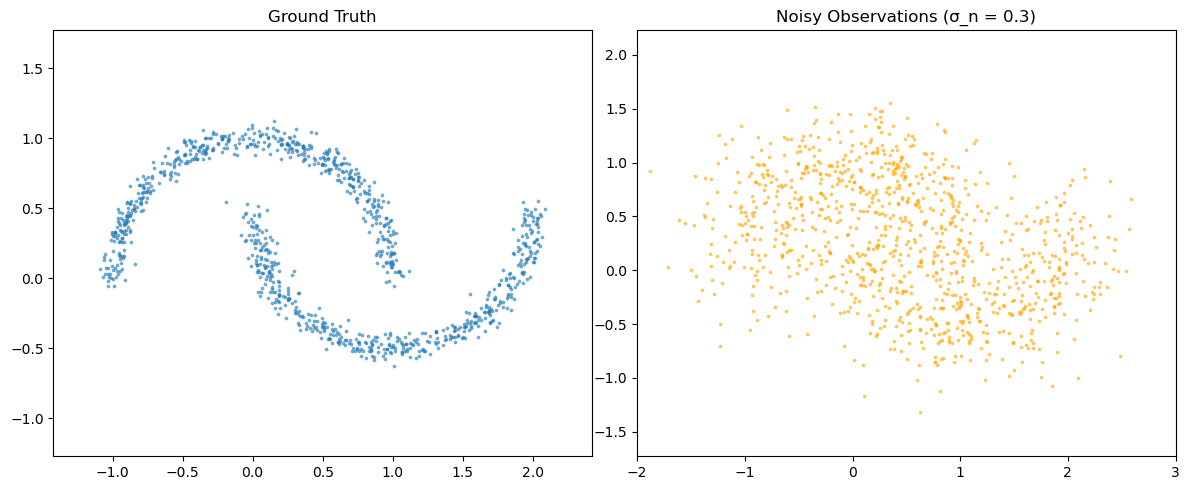

In [12]:
# Generate ground truth samples and noisy observations
key = jax.random.PRNGKey(42)
k1, k2, k3 = jax.random.split(key, 3)
n_points = 1024

clean_dist = make_two_mooons(0.)  # base_sigma=0.05 only
x_true = clean_dist.sample(k1, sample_shape=(n_points,))

# Forward model: y = x + n, n ~ N(0, sigma_obs^2 I)
sigma_obs = 0.3
y_obs = x_true + sigma_obs * jax.random.normal(k2, x_true.shape)

figure(figsize=[12, 5])
subplot(1, 2, 1); scatter(x_true[:,0], x_true[:,1], s=3, alpha=0.5)
title('Ground Truth'); axis('equal'); xlim(-2, 3); ylim(-1.5, 2)
subplot(1, 2, 2); scatter(y_obs[:,0], y_obs[:,1], s=3, alpha=0.5, c='orange')
title(f'Noisy Observations (σ_n = {sigma_obs})'); axis('equal'); xlim(-2, 3); ylim(-1.5, 2)
tight_layout()

In [13]:
# PF-ODE denoiser using diffrax — vmap over individual points
_score_single = jax.grad(log_p)  # gradient for a single (2,) point → scalar log_p

def _denoise_one(x, sigma_start, sigma_end, n_steps):
    """Denoise a single 2D point by integrating the VE probability flow ODE."""
    log_ratio = jnp.log(sigma_start / sigma_end)
    
    def sigma(t):
        return sigma_end * jnp.exp(log_ratio * t)
    
    def drift(t, y, args):
        s = sigma(t)
        return -s**2 * log_ratio * _score_single(y, s)
    
    sol = diffrax.diffeqsolve(
        diffrax.ODETerm(drift),
        diffrax.Tsit5(),
        t0=1.0, t1=0.0,
        dt0=-1.0 / n_steps,
        y0=x,
        stepsize_controller=diffrax.PIDController(rtol=1e-5, atol=1e-5),
        max_steps=4096,
    )
    return sol.ys[0]  # strip leading time dimension: (1, 2) → (2,)

def pf_ode_denoise(x_batch, sigma_start, sigma_end=0.01, n_steps=100):
    """Denoise a batch of 2D points — vmaps diffeqsolve over the batch."""
    return jax.vmap(lambda x: _denoise_one(x, sigma_start, sigma_end, n_steps))(x_batch)

In [14]:
def latino(y_obs, sigma_obs, key, N=32, sigma_max=1.0, sigma_min=0.05, n_ode_steps=100,
           delta_mode='adaptive'):
    """LATINO algorithm for denoising (A=I, no autoencoder, VE PF-ODE).
    
    Each iteration:
      1. x_noisy = x + σ_k·ε           (add diffusion noise)
      2. u = PF-ODE(x_noisy, σ_k → 0)  (denoise via prior)
      3. x = prox_{δ·g_y}(u)            (data consistency)
      
    For A=I: prox_{δ·g_y}(u) = (δ·y + σ_n²·u) / (δ + σ_n²)
    """
    sigma_schedule = np.geomspace(sigma_max, sigma_min, N)
    x = y_obs
    trajectory = [x]
    
    for k in range(N):
        sigma_k = float(sigma_schedule[k])
        key, subkey = jax.random.split(key)
        
        # 1. Add diffusion noise (VE noising)
        x_noisy = x + sigma_k * jax.random.normal(subkey, x.shape)
        
        # 2. Denoise via PF-ODE (prior)
        u = pf_ode_denoise(x_noisy, sigma_k, n_steps=n_ode_steps)
        
        # 3. Proximal step (data consistency)
        if delta_mode == 'adaptive':
            residual_norm = float(np.mean(np.sqrt(np.sum((u - y_obs)**2, axis=-1))))
            delta_k = sigma_k**2 * residual_norm / sigma_obs
        elif delta_mode == 'constant':
            delta_k = sigma_obs**2  # equal weight to prior and likelihood
        else:  # 'vanishing' - original broken schedule
            delta_k = sigma_k ** 2
            
        x = (delta_k * y_obs + sigma_obs**2 * u) / (delta_k + sigma_obs**2)
        
        rho = delta_k / (delta_k + sigma_obs**2)
        if k % 8 == 0 or k == N-1:
            print(f"  Step {k+1}/{N}: σ_k={sigma_k:.4f}, δ_k={delta_k:.4f}, "
                  f"weight on y: {rho:.3f}")
        trajectory.append(x)
    
    return x, trajectory

print("Running LATINO...")
x_recon, traj = latino(y_obs, sigma_obs, k3, N=32, delta_mode='adaptive')
print("Done!")

Running LATINO...
  Step 1/32: σ_k=1.0000, δ_k=2.6320, weight on y: 0.967
  Step 9/32: σ_k=0.4616, δ_k=0.3593, weight on y: 0.800
  Step 17/32: σ_k=0.2131, δ_k=0.0529, weight on y: 0.370
  Step 25/32: σ_k=0.0983, δ_k=0.0099, weight on y: 0.099
  Step 32/32: σ_k=0.0500, δ_k=0.0026, weight on y: 0.028
Done!


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


MSE noisy:  0.0941
MSE LATINO: 0.0999
Improvement: 0.9x


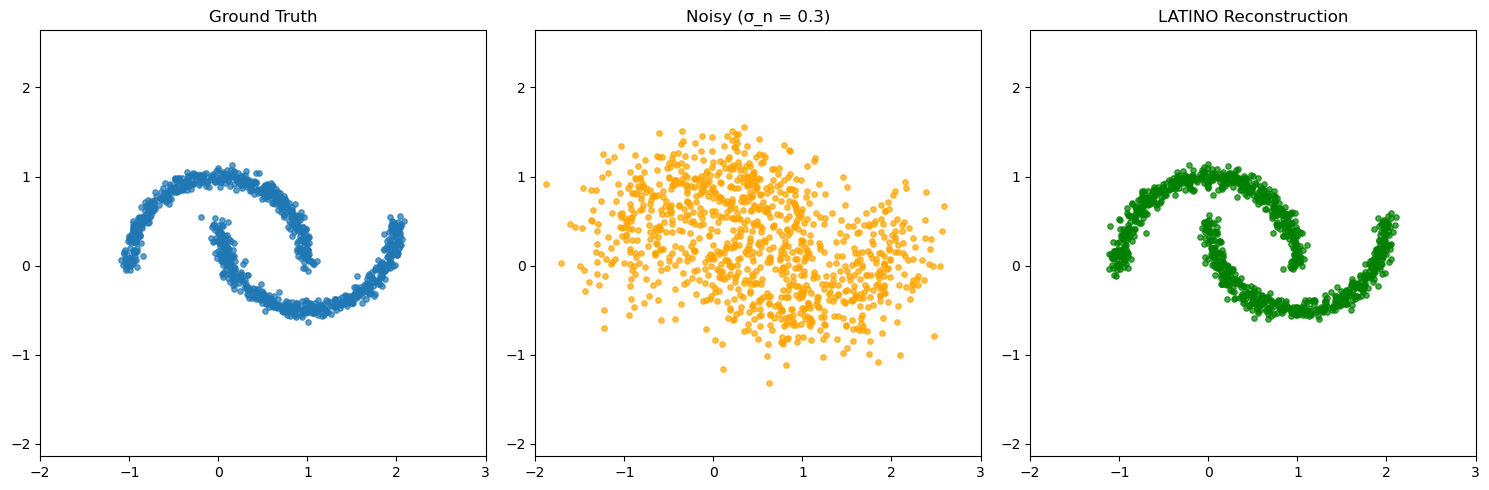

In [16]:
# Compare ground truth, noisy observations, and LATINO reconstruction
figure(figsize=[15, 5])

subplot(1, 3, 1)
scatter(x_true[:,0], x_true[:,1], s=15, alpha=0.7)
title('Ground Truth'); axis('equal'); xlim(-2, 3); ylim(-1.5, 2)

subplot(1, 3, 2)
scatter(y_obs[:,0], y_obs[:,1], s=15, alpha=0.7, c='orange')
title(f'Noisy (σ_n = {sigma_obs})'); axis('equal'); xlim(-2, 3); ylim(-1.5, 2)

subplot(1, 3, 3)
scatter(x_recon[:,0], x_recon[:,1], s=15, alpha=0.7, c='green')
title('LATINO Reconstruction'); axis('equal'); xlim(-2, 3); ylim(-1.5, 2)

tight_layout()

# Reconstruction error
mse_noisy = float(np.mean((y_obs - x_true)**2))
mse_recon = float(np.mean((x_recon - x_true)**2))
print(f"MSE noisy:  {mse_noisy:.4f}")
print(f"MSE LATINO: {mse_recon:.4f}")
print(f"Improvement: {mse_noisy/mse_recon:.1f}x")

Std of normal residuals — GT: 0.0503, Noisy: 0.2582, LATINO: 0.0601


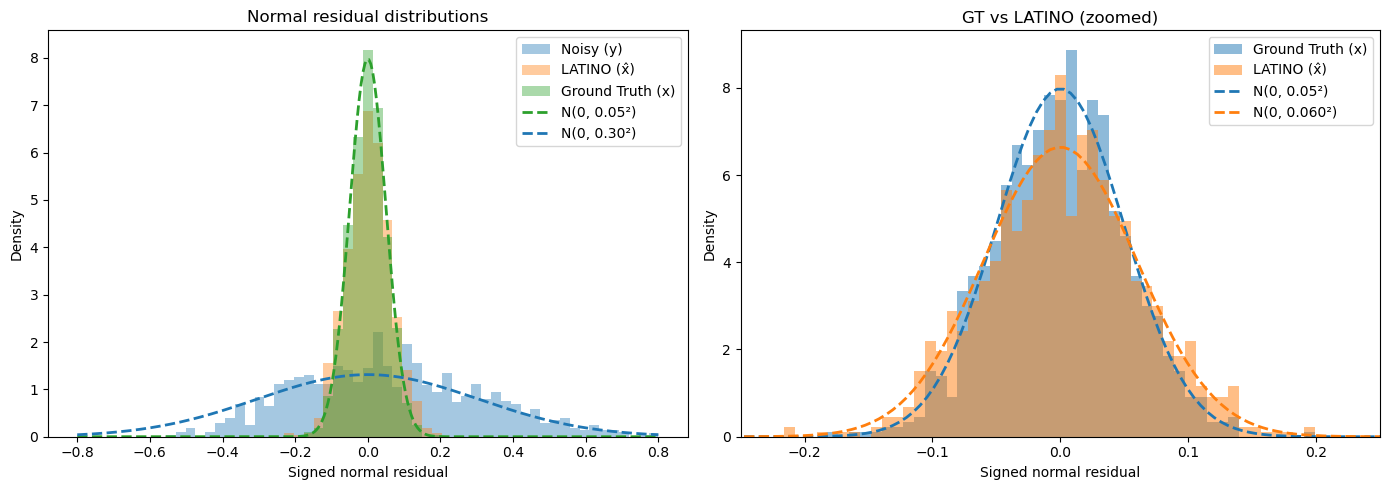

In [17]:
# Project each point onto the nearest skeleton curve point,
# then compute the signed residual along the curve normal.
from scipy.stats import norm

resolution = 1024
t = np.linspace(0, np.pi, resolution)

# Skeleton curves
outer = np.stack([np.cos(t), np.sin(t)], axis=1)
inner = np.stack([1 - np.cos(t), 1 - np.sin(t) - 0.5], axis=1)
skeleton = np.concatenate([outer, inner], axis=0)  # (2048, 2)

# Analytical normals (rotate tangent 90° clockwise: normal = (ty, -tx))
# Outer tangent: (-sin t, cos t) → normal: (cos t, sin t)
# Inner tangent: (sin t, -cos t) → normal: (-cos t, -sin t)
normal_outer = np.stack([np.cos(t), np.sin(t)], axis=1)
normal_inner = np.stack([-np.cos(t), -np.sin(t)], axis=1)
normals = np.concatenate([normal_outer, normal_inner], axis=0)  # (2048, 2)

def signed_normal_residual(points):
    """For each point, project onto nearest skeleton point and return signed normal residual."""
    diffs = points[:, None, :] - skeleton[None, :, :]  # (N, K, 2)
    nearest_idx = np.argmin(np.sum(diffs**2, axis=-1), axis=-1)  # (N,)
    residual_vec = points - skeleton[nearest_idx]  # (N, 2)
    return np.sum(residual_vec * normals[nearest_idx], axis=-1)  # (N,)

r_true = signed_normal_residual(x_true)
r_noisy = signed_normal_residual(y_obs)
r_recon = signed_normal_residual(x_recon)

# Expected: GT ~ N(0, 0.05²), noisy ~ N(0, 0.05²+0.3²)
base_sigma = 0.05
noisy_sigma = float(np.sqrt(base_sigma**2 + sigma_obs**2))
recon_std = float(np.std(r_recon))
r = np.linspace(-0.8, 0.8, 300)

figure(figsize=[14, 5])

subplot(1, 2, 1)
bins = np.linspace(-0.8, 0.8, 60)
hist(np.array(r_noisy), bins=bins, density=True, alpha=0.4, label='Noisy (y)')
hist(np.array(r_recon), bins=bins, density=True, alpha=0.4, label='LATINO (x̂)')
hist(np.array(r_true), bins=bins, density=True, alpha=0.4, label='Ground Truth (x)')
plot(r, norm.pdf(r, scale=base_sigma), 'C2--', lw=2, label=f'N(0, {base_sigma}²)')
plot(r, norm.pdf(r, scale=noisy_sigma), 'C0--', lw=2, label=f'N(0, {noisy_sigma:.2f}²)')
xlabel('Signed normal residual'); ylabel('Density')
title('Normal residual distributions')
legend()

subplot(1, 2, 2)
bins_z = np.linspace(-0.25, 0.25, 60)
hist(np.array(r_true), bins=bins_z, density=True, alpha=0.5, label='Ground Truth (x)')
hist(np.array(r_recon), bins=bins_z, density=True, alpha=0.5, label='LATINO (x̂)')
plot(r, norm.pdf(r, scale=base_sigma), 'C0--', lw=2, label=f'N(0, {base_sigma}²)')
plot(r, norm.pdf(r, scale=recon_std), 'C1--', lw=2, label=f'N(0, {recon_std:.3f}²)')
xlabel('Signed normal residual'); ylabel('Density')
title('GT vs LATINO (zoomed)')
legend(); xlim(-0.25, 0.25)

tight_layout()

print(f"Std of normal residuals — GT: {float(np.std(r_true)):.4f}, "
      f"Noisy: {float(np.std(r_noisy)):.4f}, LATINO: {recon_std:.4f}")